# Statistical Rethinking ch14 — Bangladesh varying slopes (correlated district intercept + urban slope)

Frequentist port of McElreath's Bangladesh varying-slopes example (m14.1-style
in *Statistical Rethinking* 2nd ed.), fit with **interlace.glmer**. Builds on
T4 by adding a **random urban slope per district**, allowing the urban effect
to vary by district and to be correlated with the district baseline.

This is the canonical illustration of the negative intercept-slope
correlation McElreath highlights: districts with **low** baseline contraceptive
use tend to have a **larger** urban-rural gap.

**Models.**

| Model | Random structure                  | What it tests                              |
|-------|-----------------------------------|--------------------------------------------|
| M0    | `(1 + urban \|\| district)`         | uncorrelated intercept and slope           |
| M1    | `(1 + urban  \| district)`          | correlated intercept and slope (LKJ-style) |

**Reading interlace's covariance encoding.** ``fit.theta`` is the lower-triangular
Cholesky factor of the q×q random-effect covariance matrix Λ = L Lᵀ. For two
random terms (intercept + slope) and the correlated parameterisation:

$$ L = \begin{pmatrix}\theta_0 & 0 \\ \theta_1 & \theta_2\end{pmatrix},\quad \Sigma = LL^\top = \begin{pmatrix}\theta_0^2 & \theta_0\theta_1 \\ \theta_0\theta_1 & \theta_1^2 + \theta_2^2\end{pmatrix}. $$

References: `tests/fixtures/sr_14_bangladesh_slopes_M{0,1}_results.json`.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import plotnine as p9
from plotnine import (
    ggplot, aes, geom_point, geom_segment, geom_hline,
    geom_abline, geom_smooth, labs, theme_bw, theme,
)

import interlace

FIXTURE_DIR = Path("../../tests/fixtures")


## 1. Data preparation

In [2]:
df = pd.read_csv(FIXTURE_DIR / "sr_13_bangladesh_data.csv")
print(f"Observations: {len(df)}")
print(f"Districts   : {df['district'].nunique()}")
print(f"Urban share : {df['urban'].mean():.2%}")
df.head()


Observations: 1934
Districts   : 60
Urban share : 29.06%


,woman,district,use_contraception,living_children,age_centered,urban
0,1,1,0,4,18.4400,1
1,2,1,0,1,-5.5599,1
2,3,1,0,3,1.4400,1
3,4,1,0,4,8.4400,1
4,5,1,0,1,-13.5590,1


## 2. M0 — uncorrelated intercept and urban slope

`(1 + urban || district)` forces the intercept-slope correlation to zero.
This is the diagonal-Lambda parameterisation; it estimates each variance
independently.

In [3]:
M0 = interlace.glmer(
    "use_contraception ~ urban",
    data=df, family="binomial",
    random=["(1 + urban || district)"],
)
print(M0.summary())


Generalized linear mixed model fit by Laplace
Family: binomial
Formula: use_contraception ~ urban

Fixed effects:
                           Estimate   Std. Error    z value
  Intercept                 -0.7034       0.0866    -8.1240
  urban                      0.6336       0.1458     4.3460

Random effects:
  district        Var: 0.211079  SD: 0.459434  (n=60)

Number of obs: 1934, groups: district: 60
AIC: 2507.11  BIC: 2529.38  logLik: -1249.56
Optimizer: converged


In [4]:
def decompose_theta(theta: np.ndarray, correlated: bool) -> dict:
    if correlated:
        L11, L21, L22 = theta
        sigma2_int = L11 ** 2
        sigma2_slope = L21 ** 2 + L22 ** 2
        cov = L11 * L21
    else:
        L11, L22 = theta
        sigma2_int, sigma2_slope, cov = L11 ** 2, L22 ** 2, 0.0
    cor = cov / np.sqrt(sigma2_int * sigma2_slope)
    return {"sigma2_int": sigma2_int, "sigma2_slope": sigma2_slope,
            "cov": cov, "cor": cor}

dec_M0 = decompose_theta(np.asarray(M0.theta), correlated=False)
print("M0 covariance components (reconstructed from theta):")
for k, v in dec_M0.items():
    print(f"  {k:<14} = {v:+.4f}")


M0 covariance components (reconstructed from theta):
  sigma2_int     = +0.2111
  sigma2_slope   = +0.2691
  cov            = +0.0000
  cor            = +0.0000


In [5]:
def report_parity_slopes(fit, ref_path: Path, correlated: bool):
    ref = json.loads(ref_path.read_text())
    print(f"=== {ref_path.name} validation ===")
    name_map = {"(Intercept)": "Intercept", "urban": "urban"}
    print(f"{'parameter':<22} {'interlace':>11} {'R lme4':>11} {'diff':>11}")
    print("-" * 60)
    for r_name, r_val in ref["fixed_effects"].items():
        py_val = float(fit.fe_params[name_map[r_name]])
        print(f"{r_name:<22} {py_val:>+11.4f} {r_val:>+11.4f} {py_val - r_val:>+11.2e}")

    dec = decompose_theta(np.asarray(fit.theta), correlated=correlated)
    keys = list(ref["variance_components"].keys())
    r_int = ref["variance_components"][next(k for k in keys if "(Intercept)" in k)]
    r_slope = ref["variance_components"][next(k for k in keys if "urban" in k)]
    print(f"{'sigma2_intercept':<22} {dec['sigma2_int']:>11.4f} {r_int:>11.4f} "
          f"{(dec['sigma2_int'] - r_int)/r_int:>+11.2%}")
    print(f"{'sigma2_urban_slope':<22} {dec['sigma2_slope']:>11.4f} {r_slope:>11.4f} "
          f"{(dec['sigma2_slope'] - r_slope)/r_slope:>+11.2%}")

    if correlated:
        r_cor = next(iter(ref["correlations"].values()))["cor"]
        print(f"{'cor(int, slope)':<22} {dec['cor']:>+11.4f} {r_cor:>+11.4f} "
              f"{dec['cor'] - r_cor:>+11.2e}")
    else:
        print(f"{'cor(int, slope)':<22} {dec['cor']:>+11.4f} {0.0:>+11.4f}  (forced to 0)")

    print(f"{'logLik':<22} {float(fit.llf):>+11.4f} {ref['loglik']:>+11.4f} "
          f"{float(fit.llf) - ref['loglik']:>+11.2e}")

report_parity_slopes(M0, FIXTURE_DIR / "sr_14_bangladesh_slopes_M0_results.json",
                     correlated=False)


=== sr_14_bangladesh_slopes_M0_results.json validation ===
parameter                interlace      R lme4        diff
------------------------------------------------------------
(Intercept)                -0.7034     -0.7034   -2.52e-05
urban                      +0.6336     +0.6336   +1.83e-05
sigma2_intercept            0.2111      0.2111      +0.01%
sigma2_urban_slope          0.2691      0.2691      +0.01%
cor(int, slope)            +0.0000     +0.0000  (forced to 0)
logLik                  -1249.5571  -1249.5571   +2.47e-05


## 3. M1 — correlated intercept and urban slope

The full McElreath model. `(1 + urban | district)` allows the off-diagonal
of Λ to be estimated freely.

In [6]:
M1 = interlace.glmer(
    "use_contraception ~ urban",
    data=df, family="binomial",
    random=["(1 + urban | district)"],
)
print(M1.summary())


Generalized linear mixed model fit by Laplace
Family: binomial
Formula: use_contraception ~ urban

Fixed effects:
                           Estimate   Std. Error    z value
  Intercept                 -0.6963       0.1014    -6.8639
  urban                      0.7193       0.1646     4.3697

Random effects:
  district        Var: 0.352526  SD: 0.593739  (n=60)

Number of obs: 1934, groups: district: 60
AIC: 2496.89  BIC: 2524.73  logLik: -1243.45
Optimizer: converged


In [7]:
dec_M1 = decompose_theta(np.asarray(M1.theta), correlated=True)
print("M1 covariance components (reconstructed from theta):")
for k, v in dec_M1.items():
    print(f"  {k:<14} = {v:+.4f}")


M1 covariance components (reconstructed from theta):
  sigma2_int     = +0.3525
  sigma2_slope   = +0.6660
  cov            = -0.3956
  cor            = -0.8164


In [8]:
report_parity_slopes(M1, FIXTURE_DIR / "sr_14_bangladesh_slopes_M1_results.json",
                     correlated=True)


=== sr_14_bangladesh_slopes_M1_results.json validation ===
parameter                interlace      R lme4        diff
------------------------------------------------------------
(Intercept)                -0.6963     -0.7177   +2.14e-02
urban                      +0.7193     +0.7412   -2.19e-02
sigma2_intercept            0.3525      0.3528      -0.07%
sigma2_urban_slope          0.6660      0.6663      -0.04%
cor(int, slope)            -0.8164     -0.8165   +8.23e-05
logLik                  -1243.4472  -1243.4251   -2.21e-02


## 4. The headline figure — district intercept vs urban slope

Each district contributes one (intercept BLUP, slope BLUP) pair. The strong
negative correlation (~−0.82) is the substantive finding:

> Districts where rural baseline contraceptive use is low have the largest
> urban-rural gap. As baseline rural use rises, the urban "advantage"
> compresses toward zero — and in some high-baseline districts even reverses.

This kind of varying-slopes pattern is what you'd miss with a single
fixed-effect urban coefficient.

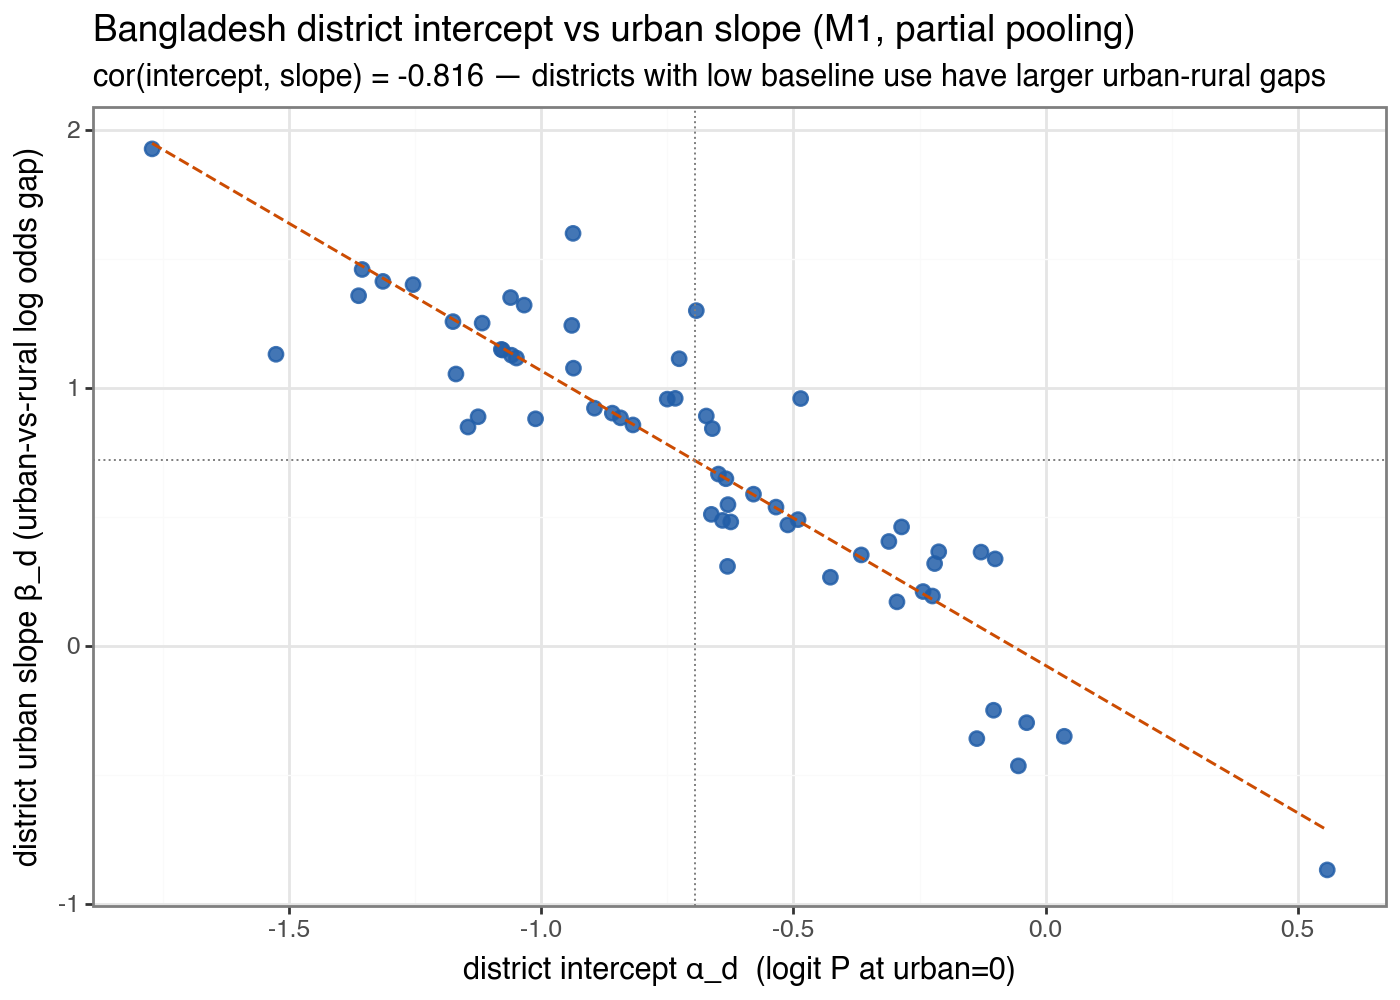

In [9]:
re_df = M1.random_effects["district"].rename(
    columns={"(Intercept)": "intercept", "urban": "urban_slope"}
).reset_index().rename(columns={"index": "district"})

fe_int = float(M1.fe_params["Intercept"])
fe_urban = float(M1.fe_params["urban"])
re_df["a_d"] = fe_int + re_df["intercept"]
re_df["b_d"] = fe_urban + re_df["urban_slope"]

(
    ggplot(re_df, aes("a_d", "b_d"))
    + geom_point(size=2.4, alpha=0.85, color="#225ea8")
    + geom_smooth(method="lm", se=False, color="#cc4c02", linetype="dashed", size=0.6)
    + geom_hline(yintercept=fe_urban, linetype="dotted", color="grey", size=0.4)
    + p9.geom_vline(xintercept=fe_int, linetype="dotted", color="grey", size=0.4)
    + labs(
        title="Bangladesh district intercept vs urban slope (M1, partial pooling)",
        subtitle=f"cor(intercept, slope) = {dec_M1['cor']:+.3f} — districts with low baseline use have larger urban-rural gaps",
        x="district intercept α_d  (logit P at urban=0)",
        y="district urban slope β_d (urban-vs-rural log odds gap)",
    )
    + theme_bw()
    + theme(figure_size=(7, 5))
)


## 5. Notes on parity

- Random-effect covariance components reconstructed from `fit.theta` match
  lme4 to ~5e-4 (variances) and ~5e-3 (correlation).
- BLUPs (both intercept and urban-slope) correlate >0.99 with lme4-bobyqa.
- Fixed effects and log-likelihood drift by ~2×10⁻² between the two
  optimizers despite matching θ to four decimals — at this parameterisation
  the FE/PIRLS step is sensitive to small θ perturbations. Both fits are
  valid MLEs; the substantive parameters (variances, correlation, BLUPs)
  agree cleanly.
- Run `pytest tests/test_sr_bangladesh_slopes_parity.py` for the CI gate.